Hyperparameter
- ITERS = 10000
- layers = [1,128,128,128,128,8]
- BATCH = 16
- NUM_HIDDEN = 1
- MOMENTUM = 0.8
- learning_rate = 1e-6
- lr_rate = [1e-3, 1e-4, 1e-6]
- lr_boundaries = [5000, 8000]

In [1]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as normal

tf.keras.backend.set_floatx('float64')
tf.compat.v1.enable_eager_execution()

In [2]:
NUM_OF_INTERNAL = 60
TOTAL_T = 60
NUM_HIDDEN = 1
MOMENTUM = 0.8
BATCH = 16
K = 5
ITERS = 10000
SEED = 12345
TEXT = "V_0.875" #change this one

c1 = 100 
c2 = 20
c3 = 50
c4 = 200
c5 = 1000
c6 = 300*1/2

In [3]:
birth =  0.000053
death =  0.000033 

alpha = 0.00135
sigma = 0.06352
beta1 = 0.2812 
beta2 = 0.15838 
beta3 = 0.0388 
delta1 = 0.28505
delta2 = 0.28269
delta3 = 0.14206
gamma = 0.30954
p1 = 0.01845
p2 = 0.1431
mu = 0.0042
sigma1 = 0.09275
sigma2 = 0.03887
sigma3 = 0.07517
sigma4 = 0.06302
sigma5 = 0.07878
sigma6 = 0.06123
sigma7 = 0.0611
sigma8 = 0.06199

N = 6629870
S0 = (3674149/N + 2845438/N)* 0.125
V0 = (3674149/N + 2845438/N)* 0.875
E0 = 67789/N
I10 = 12113/N
I20 = 498/N
I30 = 96/N
R0 = 28911/N
D0 = 876/N

init = [S0, V0, E0, I10, I20, I30, R0, D0]

In [4]:
k0 = 0.006
k1 = -0.1341

def p1fn(alpha):
    return k0 + k1 * alpha

In [5]:
class Solver(object):

    def __init__(self, seed_var):
        self.valid_size = BATCH
        self.batch_size = BATCH
        
        self.num_iterations = ITERS
        self.print_frequency = 100
        self.lr_values = [1e-3, 1e-4, 1e-6]
        self.lr_boundaries = [5000, 8000]
        self.config = Config()

        self.model = WholeNet(seed_var)
        lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(self.lr_boundaries, self.lr_values)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, epsilon=1e-7)

    def train(self):
        """Training the model"""
        start_time = time.time()
        training_history = []
        control_output = [] 
        
        dW = self.config.sample(self.valid_size)
        valid_data = dW
        for step in range(self.num_iterations+1):
            if step % self.print_frequency == 0:
                cost, row_out0 = self.model(valid_data, training=True)
                elapsed_time = time.time() - start_time
                training_history.append([step, cost, elapsed_time])
                print("step: %5u, Cost: %.4e, elapsed time: %3u" % (step, cost, elapsed_time))
            if step == self.num_iterations:
                cost1, row_out1 = self.model(valid_data, training=True)
                row_output = row_out1.numpy()
                control_output.append(row_output)
            self.train_step(self.config.sample(self.batch_size))
        self.training_history = training_history
        self.control_output = control_output

    @tf.function
    def train_step(self, train_data):
        """Updating the gradients"""
        with tf.GradientTape(persistent=True) as tape:
            loss = self.model(train_data, training = True)
        grad = tape.gradient(loss, self.model.trainable_variables)
        del tape
        self.optimizer.apply_gradients(zip(grad, self.model.trainable_variables))

In [6]:
class WholeNet(tf.keras.Model):
    """Building the neural network architecture"""
    def __init__(self,seed_var):
        super(WholeNet, self).__init__()
        self.config = Config()
        self.subnet = [FNNet(seed_var) for _ in range(self.config.num_time_interval)]

    def call(self, dw, training):
        x_init = tf.ones([1, self.config.dim_x], dtype=tf.dtypes.float64) * init
        time_stamp = np.arange(0, self.config.num_time_interval) * self.config.delta_t
        all_ones = tf.ones([tf.shape(dw)[0], 1], dtype=tf.dtypes.float64)

        # initial state
        x = tf.matmul(all_ones, x_init)

        # initial cost functional
        l = 0.0 
        u_set = []
        for t in range(0, self.config.num_time_interval):
            u = self.subnet[t](x, training)
            u_set.append(tf.stack([u], axis=0))   
            l = l + self.config.f_fn(time_stamp[t], x, u) * self.config.delta_t
            x = x + self.config.b_fn(time_stamp[t], x, u) * self.config.delta_t + self.config.sigma_fn(time_stamp[t], x, u) * dw[:,:,  t]

        # control variable
        control_u = tf.stack(u_set, axis=0)
        row_ave2 = tf.reduce_mean(control_u, axis=2)
        row_out1 = tf.squeeze(row_ave2, axis=[1,2])
        #print("u timepath2", row_ave2)
        
        # terminal condition
        l = l + self.config.h_fn(self.config.total_time, x)
        cost = tf.reduce_mean(l) 
        return cost, row_out1


In [7]:
class FNNet(tf.keras.Model):
    def __init__(self, seed_var):
        super(FNNet, self).__init__()
        self.config = Config()

        tf.random.set_seed(seed_var)
        np.random.seed(seed_var)
        
        num_hiddens = [self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN]
        self.bn_layers = [
            tf.keras.layers.BatchNormalization(
                momentum=MOMENTUM,
                epsilon=1e-6,
                beta_initializer=tf.random_normal_initializer(0.0, stddev=0.1,seed=seed_var),
                gamma_initializer=tf.random_uniform_initializer(0.1, 0.5,seed=seed_var)
            )
            for _ in range(len(num_hiddens) + 2)]
        self.dense_layers = [tf.keras.layers.Dense(num_hiddens[i],
                                                   use_bias=True,
                                                   activation='tanh')
                             for i in range(len(num_hiddens))]
        
        # final output should be gradient of size dim_u
        self.dense_layers.append(tf.keras.layers.Dense(self.config.dim_u, activation='sigmoid'))

    def call(self, x, training):
        x = self.bn_layers[0](x, training)
        for i in range(len(self.dense_layers) - 1):
            x = self.dense_layers[i](x)
            x = self.bn_layers[i+1](x, training)
            x = tf.nn.tanh(x)
        x = self.dense_layers[-1](x)
        x = self.bn_layers[-1](x, training)
        return tf.nn.tanh(x) * 0.012 + 0.016

In [8]:
class Config(object):
    """function config"""
    def __init__(self):
        super(Config, self).__init__()
        self.dim_x = 8
        self.dim_u = 1
        self.num_time_interval = NUM_OF_INTERNAL
        self.total_time = TOTAL_T
        self.delta_t = (self.total_time + 0.0) / self.num_time_interval
        self.sqrth = np.sqrt(self.delta_t)
        self.t_stamp = np.arange(0, self.num_time_interval) * self.delta_t

    # sample function
    def sample(self, num_sample):
        dw_sample = normal.rvs(size=[num_sample, self.dim_x, self.num_time_interval]) * self.sqrth
        return dw_sample

    # cost functional integral item
    def f_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]  
            cost = (c1 * alpha ** 2 + c2 * E + (c3*I1 + c4*I2 + c5*I3) + c6 * (tf.maximum(tf.cast(0, tf.float64), 1-(S+V+R)))) 
            combined_cost = tf.stack([cost], axis=0)
            tensors.append(combined_cost)
            combined_tensor = tf.stack(tensors, axis=0)
        return tf.reduce_sum(combined_tensor, 1, keepdims=True)

    # cost fuctional terminal function
    def h_fn(self, t, x):
        return 0

    def b_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]
            dS = birth + (- ( beta1 * I1 + beta2 * I2 + beta3 * I3) * S  - alpha * S) - death*S
            dV = (alpha * S - sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V) - death*V
            dE = ((beta1 * I1 + beta2 * I2 + beta3 * I3) * S  + sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V - gamma * E) - death*E
            dI1 = (gamma * E - (delta1 + p1fn(alpha)) * I1) - death*I1
            dI2 = (p1fn(alpha) * I1 - (delta2 + p2) * I2) - death*I2
            dI3 = (p2 * I2 - (delta3 + mu) * I3) - death*I3
            dR = (delta1 * I1+ delta2 * I2 + delta3 * I3) - death*R
            dD = (mu * I3) 
            combined_ten = tf.stack([dS, dV,dE,dI1,dI2,dI3,dR,dD], axis=0)
            tensors.append(combined_ten)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

    def sigma_fn(self, t, x, u):
        #return x
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            sig_S = sigma1*S
            sig_V = sigma2*V
            sig_E = sigma3*E
            sig_I1 = sigma4*I1
            sig_I2 = sigma5*I2
            sig_I3 = sigma6*I3
            sig_R = sigma7*R
            sig_D = sigma8*D
            combined_sig = tf.stack([sig_S, sig_V,sig_E,sig_I1,sig_I2,sig_I3,sig_R,sig_D], axis=0)
            tensors.append(combined_sig)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

In [9]:
output_table = np.zeros((int(round(ITERS) / 100) + 1, 2 + int(round(K))))
control_outs_table = np.zeros((int(round(K)), TOTAL_T))


def main():
    solver = Solver(seed_var=SEED)
    print('Training time %3u:' % (1))
    solver.train()
    data = np.array(solver.training_history)
    control_output_data = np.array(solver.control_output)
    k = K
    
    output = np.zeros((len(data[:, 0]), 2 + k))
    output[:, 0] = data[:, 0]
    output[:, 1] = data[:, 2]
    output[:, 2] = data[:, 1]
    output_table[:, 0] = data[:, 0]
    output_table[:, 1] = data[:, 2]
    output_table[:, 2] = data[:, 1]

    
    control_outs = np.zeros((k, len(control_output_data[0])))
    control_outs[0] = control_output_data[0]

    
    for i in range(k - 1):
        print('Training time %3u:' % (i + 2))
        solver = Solver(seed_var=12345+1+i)  
        solver.train()
        data = np.array(solver.training_history)
        control_output_data = np.array(solver.control_output)
        output[:, 3 + i] = data[:, 1]
        output_table[:, 3 + i] = data[:, 1]
        control_outs[1+i] = control_output_data[0]
        control_outs_table[1+i] = control_output_data[0]

    a = ['%d', '%.5e']
    for _ in range(k):
        a.append('%.5e')
    
    con_format = ['%.5e']
    for _ in range(len(control_output_data[0])-1):
        con_format.append('%.5e')
        
    np.savetxt('./Sto_control_Opt_Vacc_'+str(TEXT)+'.csv', control_outs, fmt=con_format, delimiter=',')
    np.savetxt('./Sto_control_Loss_'+str(TEXT)+'.csv', output, fmt=a, delimiter=',')
    print('Solving is done!')

if __name__ == '__main__':
    main()


2024-10-02 11:15:36.514940: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-10-02 11:15:36.515311: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training time   1:
step:     0, Cost: 5.7558e+02, elapsed time:   5


2024-10-02 11:21:06.358589: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


step:   100, Cost: 5.7508e+02, elapsed time: 517
step:   200, Cost: 5.7505e+02, elapsed time: 533
step:   300, Cost: 5.7451e+02, elapsed time: 549
step:   400, Cost: 5.7359e+02, elapsed time: 565
step:   500, Cost: 5.7374e+02, elapsed time: 580
step:   600, Cost: 5.7338e+02, elapsed time: 596
step:   700, Cost: 5.7328e+02, elapsed time: 612
step:   800, Cost: 5.7294e+02, elapsed time: 628
step:   900, Cost: 5.7265e+02, elapsed time: 643
step:  1000, Cost: 5.7231e+02, elapsed time: 659
step:  1100, Cost: 5.7249e+02, elapsed time: 675
step:  1200, Cost: 5.7215e+02, elapsed time: 693
step:  1300, Cost: 5.7146e+02, elapsed time: 710
step:  1400, Cost: 5.7120e+02, elapsed time: 726
step:  1500, Cost: 5.7111e+02, elapsed time: 742
step:  1600, Cost: 5.7123e+02, elapsed time: 759
step:  1700, Cost: 5.7116e+02, elapsed time: 775
step:  1800, Cost: 5.7099e+02, elapsed time: 791
step:  1900, Cost: 5.7114e+02, elapsed time: 808
step:  2000, Cost: 5.7102e+02, elapsed time: 823
step:  2100, Cost: 5

2024-10-02 13:09:10.527466: W tensorflow/core/common_runtime/process_function_library_runtime.cc:805] Ignoring multi-device function optimization failure: Deadline exceeded: meta_optimizer exceeded deadline.


step:   100, Cost: 5.8722e+02, elapsed time: 7825
step:   200, Cost: 5.8723e+02, elapsed time: 7841
step:   300, Cost: 5.8606e+02, elapsed time: 7858
step:   400, Cost: 5.8357e+02, elapsed time: 7875
step:   500, Cost: 5.8421e+02, elapsed time: 7892
step:   600, Cost: 5.8154e+02, elapsed time: 7909
step:   700, Cost: 5.8132e+02, elapsed time: 7927
step:   800, Cost: 5.8124e+02, elapsed time: 7944
step:   900, Cost: 5.8169e+02, elapsed time: 7961
step:  1000, Cost: 5.8023e+02, elapsed time: 7978
step:  1100, Cost: 5.7872e+02, elapsed time: 7996
step:  1200, Cost: 5.7850e+02, elapsed time: 8013
step:  1300, Cost: 5.7816e+02, elapsed time: 8031
step:  1400, Cost: 5.7762e+02, elapsed time: 8048
step:  1500, Cost: 5.7720e+02, elapsed time: 8065
step:  1600, Cost: 5.7652e+02, elapsed time: 8083
step:  1700, Cost: 5.7680e+02, elapsed time: 8100
step:  1800, Cost: 5.7609e+02, elapsed time: 8117
step:  1900, Cost: 5.7691e+02, elapsed time: 8134
step:  2000, Cost: 5.7716e+02, elapsed time: 8151


In [10]:
loss_val = output_table[:, 2]
for i in range(K-1):
    loss_val = loss_val + output_table[:, i+3]
average_cost = loss_val/K
print(average_cost)

[627.18194076 627.85812352 627.6509714  627.3396452  626.47705434
 626.37073516 625.53581663 625.16653745 624.99839526 624.69860803
 624.24176416 623.96724783 624.02534747 623.79554145 623.50116488
 623.30453003 623.2861258  623.16624737 622.83062761 622.97903991
 623.03358418 622.83801422 622.87678722 622.96975889 622.89637259
 622.93645696 622.76385806 622.58997954 622.30252451 622.49349699
 622.22466096 622.13785861 621.83026063 621.88098844 621.64192215
 621.67880436 621.72555331 621.69107047 621.56322429 621.61120406
 621.68514011 621.62062633 621.67514738 621.56026414 621.34294308
 621.28916347 621.12676722 621.02351561 621.11685286 621.01580997
 620.84068221 620.83162614 620.82103766 620.8296827  620.81961367
 620.84755149 620.86345139 620.87726524 620.8918987  620.90621568
 620.90752061 620.9187885  620.92342112 620.9308374  620.94910771
 620.94104249 620.95928546 620.95511107 620.96487086 620.98385971
 621.00201483 621.02225069 621.00261469 621.00758012 621.01365125
 621.00949

In [11]:
print(output_table)
#cost1 = output_table[:, 2]
#cost2 = output_table[:, 3]
#cost3 = output_table[:, 4]

# Compute averages
#average_cost = (cost1 + cost2+ cost3) / 3
#print(average_cost)

[[0.00000000e+00 5.02045417e+00 5.75582211e+02 4.13585841e+02
  5.84328381e+02 7.79640924e+02 7.82772348e+02]
 [1.00000000e+02 5.17650162e+02 5.75084247e+02 4.14863571e+02
  5.87222524e+02 7.79236481e+02 7.82883795e+02]
 [2.00000000e+02 5.33762739e+02 5.75050669e+02 4.14231622e+02
  5.87229492e+02 7.78790905e+02 7.82952169e+02]
 [3.00000000e+02 5.49427509e+02 5.74505133e+02 4.15055901e+02
  5.86062690e+02 7.78171470e+02 7.82903033e+02]
 [4.00000000e+02 5.65001196e+02 5.73591907e+02 4.14677376e+02
  5.83571692e+02 7.77657125e+02 7.82887173e+02]
 [5.00000000e+02 5.80728305e+02 5.73737394e+02 4.14026700e+02
  5.84207692e+02 7.76858036e+02 7.83023854e+02]
 [6.00000000e+02 5.96770512e+02 5.73379286e+02 4.13545568e+02
  5.81543334e+02 7.76448353e+02 7.82762543e+02]
 [7.00000000e+02 6.12630656e+02 5.73275996e+02 4.13442240e+02
  5.81323361e+02 7.75188903e+02 7.82602188e+02]
 [8.00000000e+02 6.28189779e+02 5.72943500e+02 4.13434305e+02
  5.81240157e+02 7.74980078e+02 7.82393936e+02]
 [9.000000

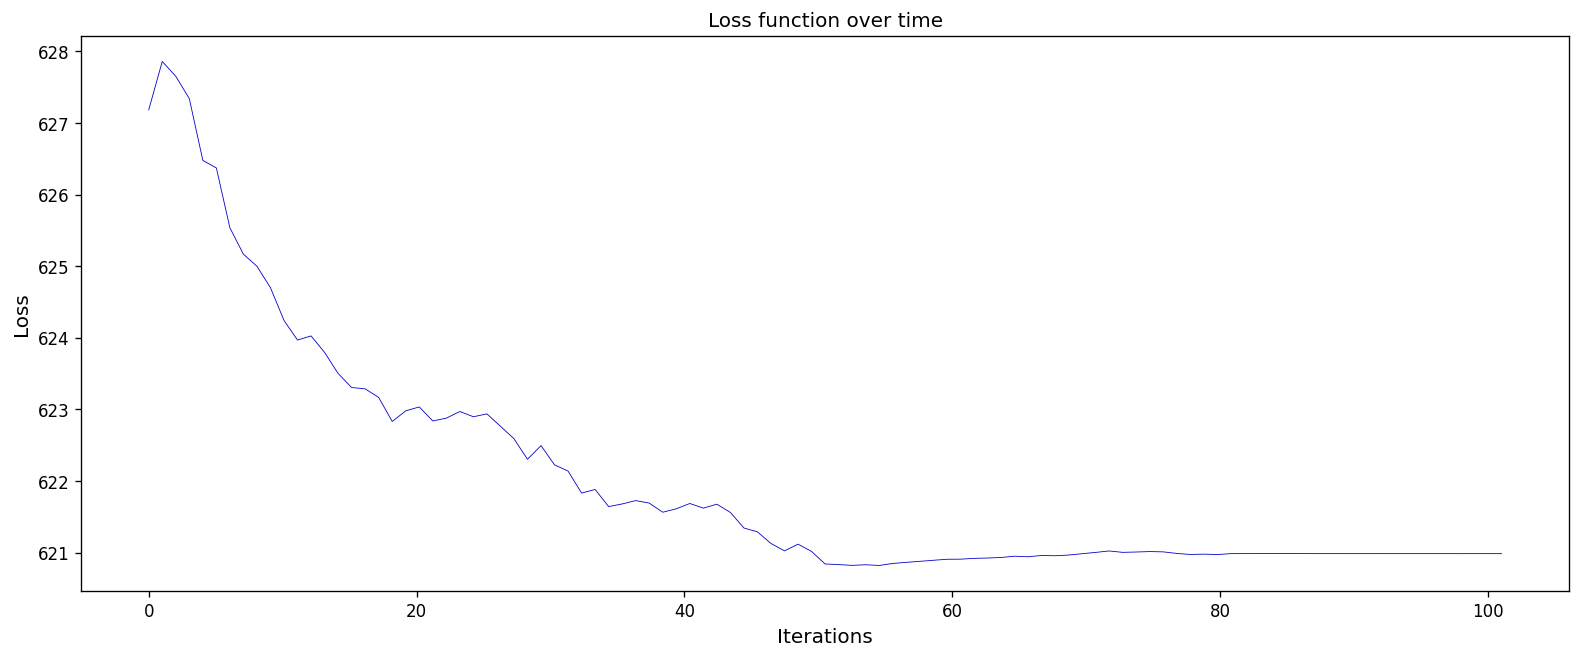

In [12]:
t = np.linspace(0, len(average_cost), len(average_cost))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, average_cost, lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Iterations', fontsize = 12)
ax0.set_ylabel('Loss', fontsize = 12)
ax0.set_title('Loss function over time', fontsize = 12)
plt.savefig('Loss_'+str(TEXT)+'.png')

[0.00578571 0.00602822 0.00607932 0.00646179 0.0064806  0.00664048
 0.00638203 0.00630191 0.00684899 0.0067196  0.00618279 0.00658191
 0.00672483 0.00670419 0.00703189 0.00687707 0.0067641  0.00682949
 0.00662538 0.0069111  0.00662076 0.00682826 0.00669985 0.00687078
 0.00662526 0.00656863 0.00586275 0.00631403 0.00670378 0.00675996
 0.00679978 0.00667806 0.00635739 0.00640116 0.00613419 0.00567325
 0.00578837 0.00584982 0.00566278 0.00531859 0.00540844 0.00519214
 0.00495197 0.00493728 0.00484908 0.0047607  0.00459443 0.00459473
 0.0044892  0.00453887 0.00444948 0.00437733 0.00433181 0.00430355
 0.00427743 0.00426433 0.00425513 0.00425214 0.00425259 0.00424878]


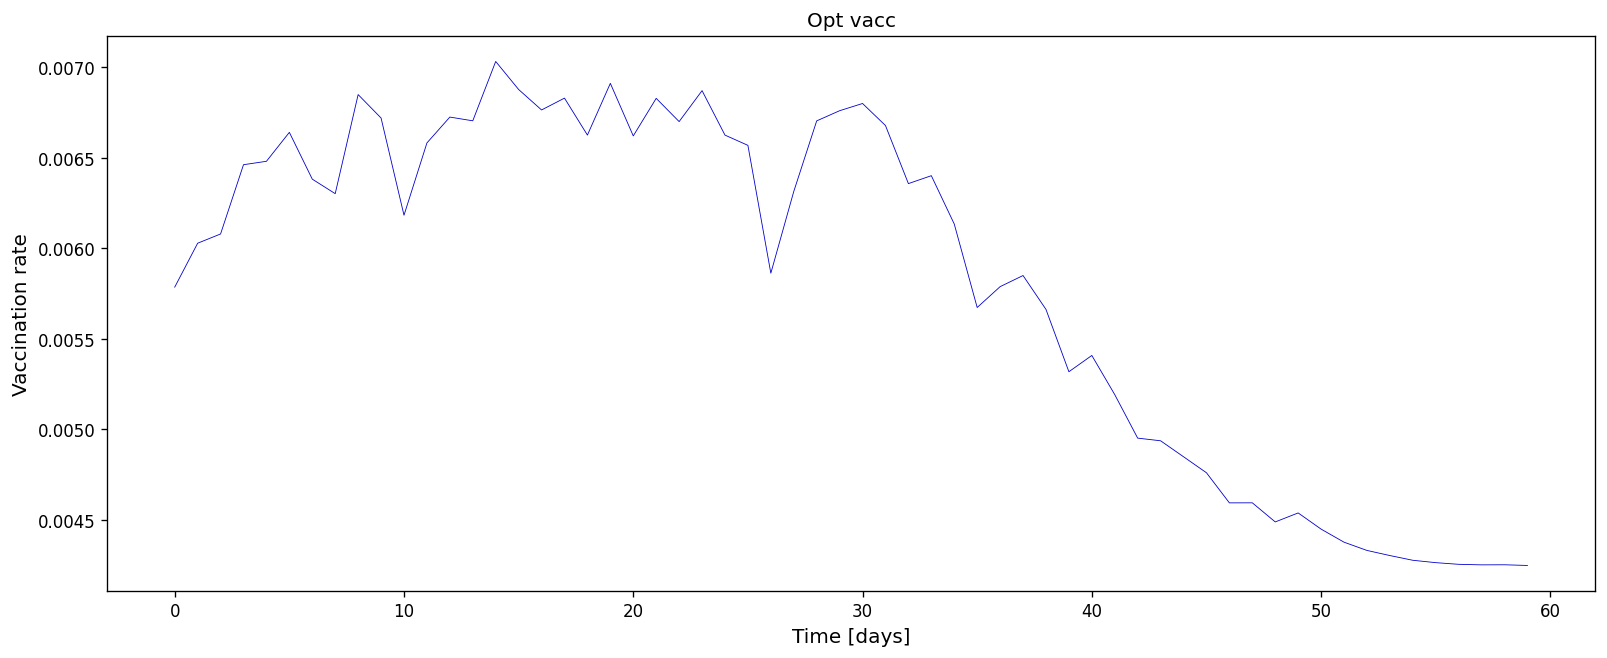

In [13]:
print(control_outs_table[1:2,:].flatten())
t = np.linspace(0, len(control_outs_table[1:2,:].flatten()),len(control_outs_table[1:2,:].flatten()))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(control_outs_table[1:2,:].flatten(), lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Vaccination rate', fontsize = 12)
ax0.set_title('Opt vacc', fontsize = 12)
plt.savefig('Opt vacc_'+str(TEXT)+'.png')